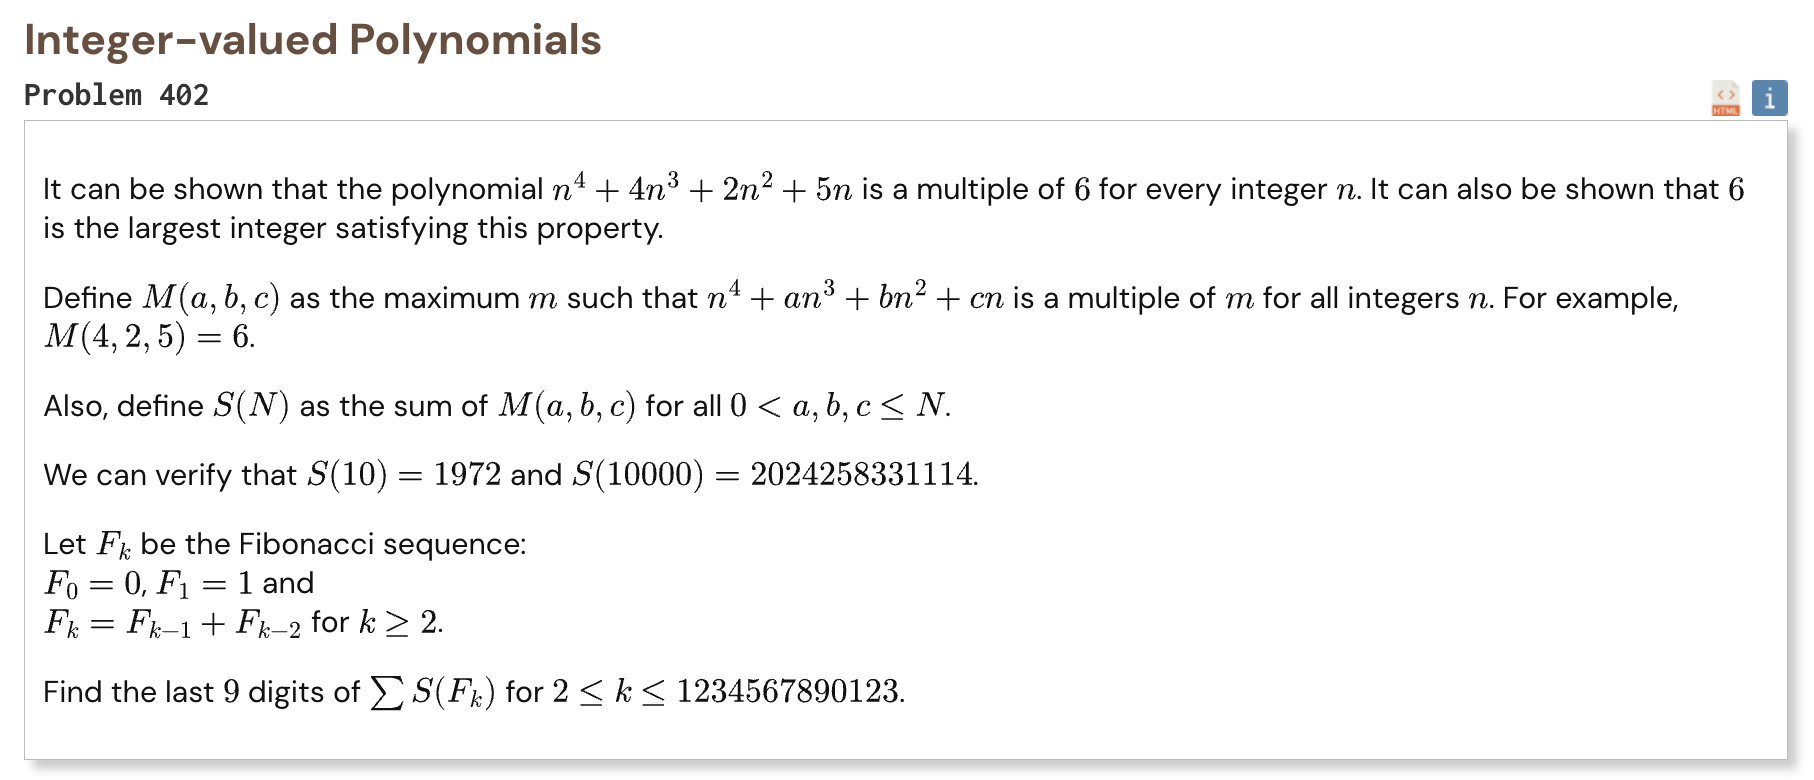

## Initial approach

-   first notice that the answer for each polynomial can only be one of a few small divisors
-   check these divisors separately instead of testing every possible gcd directly
-   count valid coefficient triples using only their remainders
-   this makes the large triple sum much easier to calculate
-   the result follows a repeating pattern based on the input modulo 24
-   Fibonacci numbers also have a repeating remainder pattern modulo 24
-   split the Fibonacci terms into 24 groups and process each group separately
-   use matrix exponentiation to jump through the enormous number of Fibonacci terms quickly

In [1]:
%%time

from math import gcd

MOD = 10**9
K = 1234567890123
DIVISORS = [1, 2, 3, 4, 6, 8, 12, 24]


def phi(n):
    result = n
    x = n
    p = 2

    while p * p <= x:
        if x % p == 0:
            while x % p == 0:
                x //= p
            result -= result // p
        p += 1

    if x > 1:
        result -= result // x

    return result


def fib(n):
    a, b = 0, 1

    for _ in range(n):
        a, b = b, a + b

    return a


valid = {}

for d in DIVISORS:
    triples = []

    for a in range(d):
        for b in range(d):
            for c in range(d):
                good = True

                for n in range(1, 5):
                    value = n**4 + a * n**3 + b * n**2 + c * n

                    if value % d != 0:
                        good = False
                        break

                if good:
                    triples.append((a, b, c))

    valid[d] = triples


def residue_counts(N, d):
    counts = [N // d] * d

    for r in range(1, N % d + 1):
        counts[r] += 1

    return counts


def S(N):
    total = 0

    for d in DIVISORS:
        counts = residue_counts(N, d)
        ways = 0

        for a, b, c in valid[d]:
            ways += counts[a] * counts[b] * counts[c]

        total += phi(d) * ways

    return total


polynomials = {}

for r in range(24):
    values = [S(24 * q + r) for q in range(4)]

    d1 = values[1] - values[0]
    d2 = values[2] - 2 * values[1] + values[0]
    d3 = values[3] - 3 * values[2] + 3 * values[1] - values[0]

    c3 = d3 // 6
    c2 = d2 // 2 - d3 // 2
    c1 = d1 - d2 // 2 + d3 // 3
    c0 = values[0]

    polynomials[r] = (c0, c1, c2, c3)


def mat_mul(A, B):
    n = len(A)
    C = [[0] * n for _ in range(n)]

    for i in range(n):
        for k in range(n):
            if A[i][k]:
                for j in range(n):
                    C[i][j] = (
                        C[i][j] + A[i][k] * B[k][j]
                    ) % MOD

    return C


def mat_vec(A, v):
    return [
        sum(a * b for a, b in zip(row, v)) % MOD
        for row in A
    ]


def apply_power(matrix, exponent, vector):
    while exponent:
        if exponent & 1:
            vector = mat_vec(matrix, vector)

        matrix = mat_mul(matrix, matrix)
        exponent //= 2

    return vector


def build_transition(A, C, coefficients):
    c0, c1, c2, c3 = coefficients

    M = [[0] * 11 for _ in range(11)]

    M[0][0] = 1

    M[1][2] = 1

    M[2][1] = -1
    M[2][2] = A
    M[2][0] = C

    M[3][5] = 1

    M[4][4] = -1
    M[4][5] = A
    M[4][2] = C

    M[5][3] = 1
    M[5][5] = A * A
    M[5][0] = C * C
    M[5][4] = -2 * A
    M[5][1] = -2 * C
    M[5][2] = 2 * A * C

    M[6][9] = 1

    M[7][8] = -1
    M[7][9] = A
    M[7][5] = C

    M[8][7] = 1
    M[8][9] = A * A
    M[8][2] = C * C
    M[8][8] = -2 * A
    M[8][4] = -2 * C
    M[8][5] = 2 * A * C

    M[9][6] = -1
    M[9][7] = 3 * A
    M[9][8] = -3 * A * A
    M[9][9] = A**3
    M[9][3] = 3 * C
    M[9][4] = -6 * A * C
    M[9][5] = 3 * A * A * C
    M[9][1] = -3 * C * C
    M[9][2] = 3 * A * C * C
    M[9][0] = C**3

    M[10][10] = 1
    M[10][0] = c0
    M[10][2] = c1
    M[10][5] = c2
    M[10][9] = c3

    return [
        [value % MOD for value in row]
        for row in M
    ]


L24 = fib(23) + fib(25)


def sum_residue_class(j):
    k0 = j if j >= 2 else j + 24

    if k0 > K:
        return 0

    count = (K - k0) // 24 + 1

    first_f = fib(k0)
    second_f = fib(k0 + 24)

    r = first_f % 24

    q0 = (first_f - r) // 24
    q1 = (second_f - r) // 24

    coefficients = polynomials[r]

    C = ((L24 - 2) * r) // 24

    matrix = build_transition(
        L24,
        C,
        coefficients
    )

    c0, c1, c2, c3 = coefficients

    first_sum = (
        c0
        + c1 * q0
        + c2 * q0**2
        + c3 * q0**3
    ) % MOD

    vector = [
        1,
        q0,
        q1,
        q0**2,
        q0 * q1,
        q1**2,
        q0**3,
        q0**2 * q1,
        q0 * q1**2,
        q1**3,
        first_sum
    ]

    vector = [x % MOD for x in vector]

    if count > 1:
        vector = apply_power(
            matrix,
            count - 1,
            vector
        )

    return vector[10]


result = sum(
    sum_residue_class(j)
    for j in range(24)
) % MOD

assert S(10) == 1972
assert S(10000) == 2024258331114

print("Result:", result)

Result: 356019862
CPU times: user 94 ms, sys: 1.9 ms, total: 95.9 ms
Wall time: 94.7 ms
